In [1]:
from pathlib import Path
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import pydicom
from tqdm import tqdm
import xml.etree.ElementTree as ET
from io import BytesIO
import zipfile


In [2]:
PROJECT_ROOT = Path(r"F:/AstraZeneca/project/chestCT/CHEST_CT_NSCLC")

LIDC_ROOT = PROJECT_ROOT / "data" / "raw" / "LIDC"
LIDC_MANIFEST_ROOT = LIDC_ROOT / "manifest-1600709154662"
LIDC_DICOM_ROOT = LIDC_MANIFEST_ROOT / "LIDC-IDRI"
LIDC_METADATA_PATH = LIDC_MANIFEST_ROOT / "metadata.csv"
LIDC_XML_ROOT = LIDC_ROOT / "tcia-lidc-xml"

PROCESSED_DIR = PROJECT_ROOT / "data" / "processed"
TABLE_DIR = PROCESSED_DIR / "tables"
FIGURE_DIR = PROCESSED_DIR / "figures"

PROCESSED_DIR.mkdir(parents=True, exist_ok=True)
TABLE_DIR.mkdir(parents=True, exist_ok=True)
FIGURE_DIR.mkdir(parents=True, exist_ok=True)

print("PROJECT_ROOT:", PROJECT_ROOT)
print("LIDC_ROOT exists:", LIDC_ROOT.exists(), LIDC_ROOT)
print("LIDC_DICOM_ROOT exists:", LIDC_DICOM_ROOT.exists(), LIDC_DICOM_ROOT)
print("LIDC_METADATA_PATH exists:", LIDC_METADATA_PATH.exists(), LIDC_METADATA_PATH)
print("LIDC_XML_ROOT exists:", LIDC_XML_ROOT.exists(), LIDC_XML_ROOT)

print("PROCESSED_DIR:", PROCESSED_DIR)
print("TABLE_DIR:", TABLE_DIR)
print("FIGURE_DIR:", FIGURE_DIR)


PROJECT_ROOT: F:\AstraZeneca\project\chestCT\CHEST_CT_NSCLC
LIDC_ROOT exists: True F:\AstraZeneca\project\chestCT\CHEST_CT_NSCLC\data\raw\LIDC
LIDC_DICOM_ROOT exists: True F:\AstraZeneca\project\chestCT\CHEST_CT_NSCLC\data\raw\LIDC\manifest-1600709154662\LIDC-IDRI
LIDC_METADATA_PATH exists: True F:\AstraZeneca\project\chestCT\CHEST_CT_NSCLC\data\raw\LIDC\manifest-1600709154662\metadata.csv
LIDC_XML_ROOT exists: True F:\AstraZeneca\project\chestCT\CHEST_CT_NSCLC\data\raw\LIDC\tcia-lidc-xml
PROCESSED_DIR: F:\AstraZeneca\project\chestCT\CHEST_CT_NSCLC\data\processed
TABLE_DIR: F:\AstraZeneca\project\chestCT\CHEST_CT_NSCLC\data\processed\tables
FIGURE_DIR: F:\AstraZeneca\project\chestCT\CHEST_CT_NSCLC\data\processed\figures


In [3]:
# Load LIDC metadata csv
lidc_metadata = pd.read_csv(LIDC_METADATA_PATH)

print("LIDC metadata shape:", lidc_metadata.shape)
display(lidc_metadata.head())
print("Columns:")
print(lidc_metadata.columns.tolist())

lidc_metadata.to_csv(TABLE_DIR / "lidc_metadata_copy.csv", index=False)


LIDC metadata shape: (1308, 17)


,Series UID,Collection,3rd Party Analysis,Data Description URI,Subject ID,Study UID,Study Description,Study Date,Series Description,Manufacturer,Modality,SOP Class Name,SOP Class UID,Number of Images,File Size,File Location,Download Timestamp
0,1.3.6.1.4.1.14519.5.2.1.6279.6001.493562949900...,LIDC-IDRI,NaN,https://doi.org/10.7937/K9/TCIA.2015.LO9QL9SX,LIDC-IDRI-0002,1.3.6.1.4.1.14519.5.2.1.6279.6001.116951808801...,NaN,01-01-2000,NaN,GE MEDICAL SYSTEMS,DX,Digital X-Ray Image Storage - For Presentation,1.2.840.10008.5.1.4.1.1.1.1,1,6.91 MB,.\LIDC-IDRI\LIDC-IDRI-0002\01-01-2000-NA-NA-26...,2026-05-28T13:52:01.568
1,1.3.6.1.4.1.14519.5.2.1.6279.6001.141365756818...,LIDC-IDRI,NaN,https://doi.org/10.7937/K9/TCIA.2015.LO9QL9SX,LIDC-IDRI-0001,1.3.6.1.4.1.14519.5.2.1.6279.6001.175012972118...,NaN,01-01-2000,NaN,GE MEDICAL SYSTEMS,DX,Digital X-Ray Image Storage - For Presentation,1.2.840.10008.5.1.4.1.1.1.1,2,16.36 MB,.\LIDC-IDRI\LIDC-IDRI-0001\01-01-2000-NA-NA-35...,2026-05-28T13:52:11.413
2,1.3.6.1.4.1.14519.5.2.1.6279.6001.179049373636...,LIDC-IDRI,NaN,https://doi.org/10.7937/K9/TCIA.2015.LO9QL9SX,LIDC-IDRI-0001,1.3.6.1.4.1.14519.5.2.1.6279.6001.298806137288...,NaN,01-01-2000,NaN,GE MEDICAL SYSTEMS,CT,CT Image Storage,1.2.840.10008.5.1.4.1.1.2,133,70.33 MB,.\LIDC-IDRI\LIDC-IDRI-0001\01-01-2000-NA-NA-30...,2026-05-28T13:53:04.604
3,1.3.6.1.4.1.14519.5.2.1.6279.6001.170706757615...,LIDC-IDRI,NaN,https://doi.org/10.7937/K9/TCIA.2015.LO9QL9SX,LIDC-IDRI-0003,1.3.6.1.4.1.14519.5.2.1.6279.6001.101370605276...,NaN,01-01-2000,NaN,GE MEDICAL SYSTEMS,CT,CT Image Storage,1.2.840.10008.5.1.4.1.1.2,140,74.11 MB,.\LIDC-IDRI\LIDC-IDRI-0003\01-01-2000-NA-NA-94...,2026-05-28T13:53:24.853
4,1.3.6.1.4.1.14519.5.2.1.6279.6001.142026812390...,LIDC-IDRI,NaN,https://doi.org/10.7937/K9/TCIA.2015.LO9QL9SX,LIDC-IDRI-0003,1.3.6.1.4.1.14519.5.2.1.6279.6001.202063331127...,NaN,01-01-2000,NaN,GE MEDICAL SYSTEMS,DX,Digital X-Ray Image Storage - For Presentation,1.2.840.10008.5.1.4.1.1.1.1,5,38.59 MB,.\LIDC-IDRI\LIDC-IDRI-0003\01-01-2000-NA-NA-59...,2026-05-28T13:53:28.072


Columns:
['Series UID', 'Collection', '3rd Party Analysis', 'Data Description URI', 'Subject ID', 'Study UID', 'Study Description', 'Study Date', 'Series Description', 'Manufacturer', 'Modality', 'SOP Class Name', 'SOP Class UID', 'Number of Images', 'File Size', 'File Location', 'Download Timestamp']


In [4]:
patient_dirs = sorted([
    p for p in LIDC_DICOM_ROOT.glob("LIDC-IDRI-*")
    if p.is_dir()
])

print("Number of LIDC patient folders:", len(patient_dirs))
print("First 10 patient folders:")

for p in patient_dirs[:10]:
    print(p.name)


Number of LIDC patient folders:

 1010
First 10 patient folders:
LIDC-IDRI-0001
LIDC-IDRI-0002
LIDC-IDRI-0003
LIDC-IDRI-0004
LIDC-IDRI-0005
LIDC-IDRI-0006
LIDC-IDRI-0007
LIDC-IDRI-0008
LIDC-IDRI-0009
LIDC-IDRI-0010


In [5]:
xml_files = sorted(LIDC_XML_ROOT.rglob("*.xml"))

print("Number of XML files:", len(xml_files))
print("First 10 XML files:")

for f in xml_files[:10]:
    print(f)


Number of XML files: 1318
First 10 XML files:
F:\AstraZeneca\project\chestCT\CHEST_CT_NSCLC\data\raw\LIDC\tcia-lidc-xml\157\158.xml
F:\AstraZeneca\project\chestCT\CHEST_CT_NSCLC\data\raw\LIDC\tcia-lidc-xml\157\159.xml
F:\AstraZeneca\project\chestCT\CHEST_CT_NSCLC\data\raw\LIDC\tcia-lidc-xml\157\160.xml
F:\AstraZeneca\project\chestCT\CHEST_CT_NSCLC\data\raw\LIDC\tcia-lidc-xml\157\161.xml
F:\AstraZeneca\project\chestCT\CHEST_CT_NSCLC\data\raw\LIDC\tcia-lidc-xml\157\162.xml
F:\AstraZeneca\project\chestCT\CHEST_CT_NSCLC\data\raw\LIDC\tcia-lidc-xml\157\163.xml
F:\AstraZeneca\project\chestCT\CHEST_CT_NSCLC\data\raw\LIDC\tcia-lidc-xml\157\164.xml
F:\AstraZeneca\project\chestCT\CHEST_CT_NSCLC\data\raw\LIDC\tcia-lidc-xml\157\165.xml
F:\AstraZeneca\project\chestCT\CHEST_CT_NSCLC\data\raw\LIDC\tcia-lidc-xml\157\166.xml
F:\AstraZeneca\project\chestCT\CHEST_CT_NSCLC\data\raw\LIDC\tcia-lidc-xml\157\167.xml


In [6]:
sample_patient = patient_dirs[0]

all_files = [f for f in sample_patient.rglob("*") if f.is_file()]

print("Sample patient:", sample_patient.name)
print("Number of files under this patient:", len(all_files))

dicom_files = []

for f in all_files:
    try:
        ds = pydicom.dcmread(str(f), stop_before_pixels=True, force=True)
        if getattr(ds, "Modality", None) == "CT":
            dicom_files.append(f)
    except Exception:
        pass

print("Number of CT DICOM files:", len(dicom_files))
print("First CT DICOM file:", dicom_files[0] if dicom_files else None)


Sample patient: LIDC-IDRI-0001
Number of files under this patient: 137


Number of CT DICOM files: 133
First CT DICOM file: F:\AstraZeneca\project\chestCT\CHEST_CT_NSCLC\data\raw\LIDC\manifest-1600709154662\LIDC-IDRI\LIDC-IDRI-0001\01-01-2000-NA-NA-30178\3000566.000000-NA-03192\1-001.dcm


PatientID: LIDC-IDRI-0001
StudyInstanceUID: 1.3.6.1.4.1.14519.5.2.1.6279.6001.298806137288633453246975630178
SeriesInstanceUID: 1.3.6.1.4.1.14519.5.2.1.6279.6001.179049373636438705059720603192
Rows, Columns: 512 512
PixelSpacing: [0.703125, 0.703125]
SliceThickness: 2.500000
RescaleSlope: 1.0
RescaleIntercept: -1024.0
HU range: -2048.0 3071.0


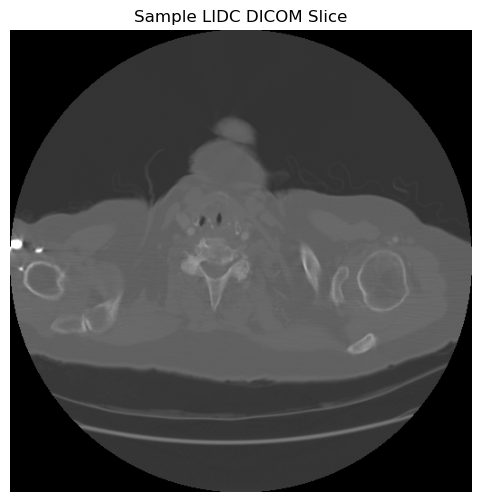

In [7]:
ds = pydicom.dcmread(str(dicom_files[0]), force=True)

pixel_array = ds.pixel_array.astype(np.float32)

slope = float(getattr(ds, "RescaleSlope", 1))
intercept = float(getattr(ds, "RescaleIntercept", 0))

hu_image = pixel_array * slope + intercept

print("PatientID:", getattr(ds, "PatientID", None))
print("StudyInstanceUID:", getattr(ds, "StudyInstanceUID", None))
print("SeriesInstanceUID:", getattr(ds, "SeriesInstanceUID", None))
print("Rows, Columns:", ds.Rows, ds.Columns)
print("PixelSpacing:", getattr(ds, "PixelSpacing", None))
print("SliceThickness:", getattr(ds, "SliceThickness", None))
print("RescaleSlope:", slope)
print("RescaleIntercept:", intercept)
print("HU range:", hu_image.min(), hu_image.max())

plt.figure(figsize=(6, 6))
plt.imshow(hu_image, cmap="gray")
plt.title("Sample LIDC DICOM Slice")
plt.axis("off")
plt.show()

plt.imsave(FIGURE_DIR / "lidc_sample_slice.png", hu_image, cmap="gray")


In [8]:
def read_dicom_header(file_path):
    try:
        ds = pydicom.dcmread(str(file_path), stop_before_pixels=True, force=True)

        if not hasattr(ds, "SeriesInstanceUID"):
            return None

        return {
            "PatientID": getattr(ds, "PatientID", None),
            "StudyInstanceUID": getattr(ds, "StudyInstanceUID", None),
            "SeriesInstanceUID": getattr(ds, "SeriesInstanceUID", None),
            "Modality": getattr(ds, "Modality", None),
            "Rows": getattr(ds, "Rows", None),
            "Columns": getattr(ds, "Columns", None),
            "SliceThickness": getattr(ds, "SliceThickness", None),
            "PixelSpacing": str(getattr(ds, "PixelSpacing", None)),
            "Manufacturer": getattr(ds, "Manufacturer", None),
            "ConvolutionKernel": getattr(ds, "ConvolutionKernel", None),
        }

    except Exception:
        return None
    
inventory_path = TABLE_DIR / "lidc_series_inventory.csv"

if inventory_path.exists():
    print("Existing inventory found. Loading:", inventory_path)
    lidc_series_df = pd.read_csv(inventory_path)
else:
    series_records = []

    for patient_dir in tqdm(patient_dirs, desc="Scanning LIDC patients"):
        files = [f for f in patient_dir.rglob("*") if f.is_file()]

        patient_headers = []

        for f in files:
            header = read_dicom_header(f)
            if header is not None:
                header["patient_folder"] = patient_dir.name
                header["file_path"] = str(f)
                patient_headers.append(header)

        if len(patient_headers) == 0:
            continue

        patient_df = pd.DataFrame(patient_headers)

        grouped = (
            patient_df
            .groupby(
                [
                    "patient_folder",
                    "PatientID",
                    "StudyInstanceUID",
                    "SeriesInstanceUID",
                    "Modality",
                    "Rows",
                    "Columns",
                    "SliceThickness",
                    "PixelSpacing",
                    "Manufacturer",
                    "ConvolutionKernel",
                ],
                dropna=False
            )
            .size()
            .reset_index(name="num_slices")
        )

        series_records.append(grouped)

    lidc_series_df = pd.concat(series_records, ignore_index=True)
    lidc_series_df.to_csv(inventory_path, index=False)

display(lidc_series_df.head())

print("Total series:", len(lidc_series_df))
print("CT series:", (lidc_series_df["Modality"] == "CT").sum())
print("Saved to:", inventory_path)


Existing inventory found. Loading: F:\AstraZeneca\project\chestCT\CHEST_CT_NSCLC\data\processed\tables\lidc_series_inventory.csv


,patient_folder,PatientID,StudyInstanceUID,SeriesInstanceUID,Modality,Rows,Columns,SliceThickness,PixelSpacing,Manufacturer,ConvolutionKernel,num_slices
0,LIDC-IDRI-0001,LIDC-IDRI-0001,1.3.6.1.4.1.14519.5.2.1.6279.6001.175012972118...,1.3.6.1.4.1.14519.5.2.1.6279.6001.141365756818...,DX,2022,2022,NaN,NaN,GE MEDICAL SYSTEMS,NaN,2
1,LIDC-IDRI-0001,LIDC-IDRI-0001,1.3.6.1.4.1.14519.5.2.1.6279.6001.298806137288...,1.3.6.1.4.1.14519.5.2.1.6279.6001.179049373636...,CT,512,512,2.50,"[0.703125, 0.703125]",GE MEDICAL SYSTEMS,STANDARD,133
2,LIDC-IDRI-0002,LIDC-IDRI-0002,1.3.6.1.4.1.14519.5.2.1.6279.6001.116951808801...,1.3.6.1.4.1.14519.5.2.1.6279.6001.493562949900...,DX,2007,1721,NaN,NaN,GE MEDICAL SYSTEMS,NaN,1
3,LIDC-IDRI-0002,LIDC-IDRI-0002,1.3.6.1.4.1.14519.5.2.1.6279.6001.490157381160...,1.3.6.1.4.1.14519.5.2.1.6279.6001.619372068417...,CT,512,512,1.25,"[0.681641, 0.681641]",GE MEDICAL SYSTEMS,STANDARD,261
4,LIDC-IDRI-0003,LIDC-IDRI-0003,1.3.6.1.4.1.14519.5.2.1.6279.6001.101370605276...,1.3.6.1.4.1.14519.5.2.1.6279.6001.170706757615...,CT,512,512,2.50,"[0.820312, 0.820312]",GE MEDICAL SYSTEMS,STANDARD,140


Total series: 1362
CT series: 1018
Saved to: F:\AstraZeneca\project\chestCT\CHEST_CT_NSCLC\data\processed\tables\lidc_series_inventory.csv


In [9]:
lidc_ct_series_df = lidc_series_df[lidc_series_df["Modality"] == "CT"].copy()

main_ct_series_df = (
    lidc_ct_series_df
    .sort_values(["patient_folder", "num_slices"], ascending=[True, False])
    .groupby("patient_folder")
    .head(1)
    .reset_index(drop=True)
)

main_ct_series_path = TABLE_DIR / "lidc_main_ct_series.csv"
main_ct_series_df.to_csv(main_ct_series_path, index=False)

display(main_ct_series_df.head())

print("Number of main CT series:", len(main_ct_series_df))
print("Saved to:", main_ct_series_path)


,patient_folder,PatientID,StudyInstanceUID,SeriesInstanceUID,Modality,Rows,Columns,SliceThickness,PixelSpacing,Manufacturer,ConvolutionKernel,num_slices
0,LIDC-IDRI-0001,LIDC-IDRI-0001,1.3.6.1.4.1.14519.5.2.1.6279.6001.298806137288...,1.3.6.1.4.1.14519.5.2.1.6279.6001.179049373636...,CT,512,512,2.50,"[0.703125, 0.703125]",GE MEDICAL SYSTEMS,STANDARD,133
1,LIDC-IDRI-0002,LIDC-IDRI-0002,1.3.6.1.4.1.14519.5.2.1.6279.6001.490157381160...,1.3.6.1.4.1.14519.5.2.1.6279.6001.619372068417...,CT,512,512,1.25,"[0.681641, 0.681641]",GE MEDICAL SYSTEMS,STANDARD,261
2,LIDC-IDRI-0003,LIDC-IDRI-0003,1.3.6.1.4.1.14519.5.2.1.6279.6001.101370605276...,1.3.6.1.4.1.14519.5.2.1.6279.6001.170706757615...,CT,512,512,2.50,"[0.820312, 0.820312]",GE MEDICAL SYSTEMS,STANDARD,140
3,LIDC-IDRI-0004,LIDC-IDRI-0004,1.3.6.1.4.1.14519.5.2.1.6279.6001.191425307197...,1.3.6.1.4.1.14519.5.2.1.6279.6001.323541312620...,CT,512,512,1.25,"[0.822266, 0.822266]",GE MEDICAL SYSTEMS,STANDARD,241
4,LIDC-IDRI-0005,LIDC-IDRI-0005,1.3.6.1.4.1.14519.5.2.1.6279.6001.190188259083...,1.3.6.1.4.1.14519.5.2.1.6279.6001.129007566048...,CT,512,512,2.50,"[0.664062, 0.664062]",GE MEDICAL SYSTEMS,STANDARD,133


Number of main CT series: 1010
Saved to: F:\AstraZeneca\project\chestCT\CHEST_CT_NSCLC\data\processed\tables\lidc_main_ct_series.csv


In [10]:
def load_lidc_volume_from_patient(patient_dir: Path, series_uid: str):
    dicom_paths = []

    for f in patient_dir.rglob("*"):
        if not f.is_file():
            continue

        try:
            ds = pydicom.dcmread(str(f), stop_before_pixels=True, force=True)

            if getattr(ds, "SeriesInstanceUID", None) == series_uid:
                dicom_paths.append(f)

        except Exception:
            pass

    slices = []

    for f in dicom_paths:
        try:
            ds = pydicom.dcmread(str(f), force=True)

            if hasattr(ds, "pixel_array"):
                slices.append(ds)

        except Exception:
            pass

    if len(slices) == 0:
        raise ValueError("No readable DICOM slices found for this series.")

    def get_slice_position(ds):
        if hasattr(ds, "ImagePositionPatient"):
            return float(ds.ImagePositionPatient[2])
        if hasattr(ds, "SliceLocation"):
            return float(ds.SliceLocation)
        return float(getattr(ds, "InstanceNumber", 0))

    slices = sorted(slices, key=get_slice_position)

    volume = np.stack(
        [s.pixel_array.astype(np.float32) for s in slices],
        axis=0
    )

    slope = float(getattr(slices[0], "RescaleSlope", 1))
    intercept = float(getattr(slices[0], "RescaleIntercept", 0))

    volume_hu = volume * slope + intercept

    spacing = {
        "z": float(getattr(slices[0], "SliceThickness", 1)),
        "y": float(slices[0].PixelSpacing[0]),
        "x": float(slices[0].PixelSpacing[1]),
    }

    return volume_hu, spacing, slices

sample_main = main_ct_series_df.iloc[0]

sample_patient_dir = LIDC_DICOM_ROOT / sample_main["patient_folder"]
sample_series_uid = sample_main["SeriesInstanceUID"]

volume_hu, spacing, slices = load_lidc_volume_from_patient(
    sample_patient_dir,
    sample_series_uid
)

print("Sample patient:", sample_main["patient_folder"])
print("SeriesInstanceUID:", sample_series_uid)
print("Volume shape:", volume_hu.shape)   # z, y, x
print("Spacing:", spacing)
print("HU range:", volume_hu.min(), volume_hu.max())


Sample patient: LIDC-IDRI-0001
SeriesInstanceUID: 1.3.6.1.4.1.14519.5.2.1.6279.6001.179049373636438705059720603192
Volume shape: (133, 512, 512)
Spacing: {'z': 2.5, 'y': 0.703125, 'x': 0.703125}
HU range: -2048.0 3071.0


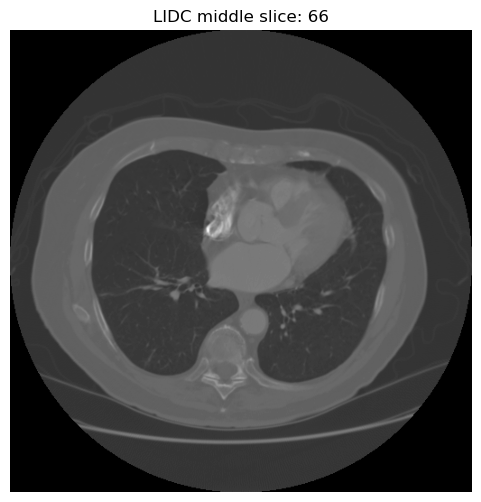

Saved figure to: F:\AstraZeneca\project\chestCT\CHEST_CT_NSCLC\data\processed\figures\lidc_sample_middle_slice.png


In [11]:
mid = volume_hu.shape[0] // 2

plt.figure(figsize=(6, 6))
plt.imshow(volume_hu[mid], cmap="gray")
plt.title(f"LIDC middle slice: {mid}")
plt.axis("off")
plt.show()

plt.imsave(
    FIGURE_DIR / "lidc_sample_middle_slice.png",
    volume_hu[mid],
    cmap="gray"
)

print("Saved figure to:", FIGURE_DIR / "lidc_sample_middle_slice.png")


In [12]:
def local_name(tag):
    return tag.split("}", 1)[-1] if "}" in tag else tag


def find_first_text(root, target_name):
    for elem in root.iter():
        if local_name(elem.tag) == target_name:
            return elem.text
    return None


def get_child_text(parent, target_name):
    for child in parent:
        if local_name(child.tag) == target_name:
            return child.text
    return None


def parse_lidc_xml(xml_path: Path):
    tree = ET.parse(xml_path)
    root = tree.getroot()

    series_uid = (
        find_first_text(root, "SeriesInstanceUid")
        or find_first_text(root, "SeriesInstanceUID")
        or find_first_text(root, "seriesInstanceUid")
    )

    study_uid = (
        find_first_text(root, "StudyInstanceUID")
        or find_first_text(root, "StudyInstanceUid")
        or find_first_text(root, "studyInstanceUid")
    )

    rows = []

    reading_sessions = [
        elem for elem in root.iter()
        if local_name(elem.tag) == "readingSession"
    ]

    for reader_index, session in enumerate(reading_sessions, start=1):

        nodules = [
            elem for elem in session
            if local_name(elem.tag) == "unblindedReadNodule"
        ]

        for nodule in nodules:
            nodule_id = get_child_text(nodule, "noduleID")

            characteristics = None

            for child in nodule:
                if local_name(child.tag) == "characteristics":
                    characteristics = child
                    break

            malignancy = None
            subtlety = None
            internal_structure = None
            calcification = None
            sphericity = None
            margin = None
            lobulation = None
            spiculation = None
            texture = None

            if characteristics is not None:
                malignancy = get_child_text(characteristics, "malignancy")
                subtlety = get_child_text(characteristics, "subtlety")
                internal_structure = get_child_text(characteristics, "internalStructure")
                calcification = get_child_text(characteristics, "calcification")
                sphericity = get_child_text(characteristics, "sphericity")
                margin = get_child_text(characteristics, "margin")
                lobulation = get_child_text(characteristics, "lobulation")
                spiculation = get_child_text(characteristics, "spiculation")
                texture = get_child_text(characteristics, "texture")

            roi_count = 0
            edge_point_count = 0

            z_positions = []
            x_points = []
            y_points = []

            for roi in nodule.iter():
                if local_name(roi.tag) == "roi":
                    roi_count += 1

                    z_text = get_child_text(roi, "imageZposition")

                    if z_text is not None:
                        try:
                            z_positions.append(float(z_text))
                        except ValueError:
                            pass

                    for edge_map in roi:
                        if local_name(edge_map.tag) == "edgeMap":
                            x_text = get_child_text(edge_map, "xCoord")
                            y_text = get_child_text(edge_map, "yCoord")

                            if x_text is not None and y_text is not None:
                                try:
                                    x_points.append(float(x_text))
                                    y_points.append(float(y_text))
                                    edge_point_count += 1
                                except ValueError:
                                    pass

            row = {
                "xml_file": str(xml_path),
                "xml_name": xml_path.name,
                "StudyInstanceUID": study_uid,
                "SeriesInstanceUID": series_uid,
                "reader_id": reader_index,
                "nodule_id": nodule_id,
                "malignancy": malignancy,
                "subtlety": subtlety,
                "internal_structure": internal_structure,
                "calcification": calcification,
                "sphericity": sphericity,
                "margin": margin,
                "lobulation": lobulation,
                "spiculation": spiculation,
                "texture": texture,
                "roi_count": roi_count,
                "edge_point_count": edge_point_count,
                "z_min": min(z_positions) if z_positions else np.nan,
                "z_max": max(z_positions) if z_positions else np.nan,
                "x_min": min(x_points) if x_points else np.nan,
                "x_max": max(x_points) if x_points else np.nan,
                "y_min": min(y_points) if y_points else np.nan,
                "y_max": max(y_points) if y_points else np.nan,
            }

            rows.append(row)

    return rows


In [13]:
xml_nodules_path = TABLE_DIR / "lidc_xml_nodules_raw.csv"

if xml_nodules_path.exists():
    print("Existing XML nodule table found. Loading:", xml_nodules_path)
    lidc_xml_nodules_df = pd.read_csv(xml_nodules_path)
else:
    all_nodule_rows = []

    for xml_file in tqdm(xml_files, desc="Parsing LIDC XML files"):
        try:
            rows = parse_lidc_xml(xml_file)
            all_nodule_rows.extend(rows)
        except Exception as e:
            print("Failed:", xml_file, e)

    lidc_xml_nodules_df = pd.DataFrame(all_nodule_rows)
    lidc_xml_nodules_df.to_csv(xml_nodules_path, index=False)

display(lidc_xml_nodules_df.head())
print("XML nodule table shape:", lidc_xml_nodules_df.shape)
print("Saved to:", xml_nodules_path)


Existing XML nodule table found. Loading: F:\AstraZeneca\project\chestCT\CHEST_CT_NSCLC\data\processed\tables\lidc_xml_nodules_raw.csv


,xml_file,xml_name,StudyInstanceUID,SeriesInstanceUID,reader_id,nodule_id,malignancy,subtlety,internal_structure,calcification,...,spiculation,texture,roi_count,edge_point_count,z_min,z_max,x_min,x_max,y_min,y_max
0,F:\AstraZeneca\project\chestCT\CHEST_CT_NSCLC\...,158.xml,1.3.6.1.4.1.14519.5.2.1.6279.6001.339170810277...,1.3.6.1.4.1.14519.5.2.1.6279.6001.303494235102...,1,0,NaN,NaN,NaN,NaN,...,NaN,NaN,1,1,1604.5,1604.5,177.0,177.0,353.0,353.0
1,F:\AstraZeneca\project\chestCT\CHEST_CT_NSCLC\...,158.xml,1.3.6.1.4.1.14519.5.2.1.6279.6001.339170810277...,1.3.6.1.4.1.14519.5.2.1.6279.6001.303494235102...,1,3,3.0,5.0,1.0,6.0,...,1.0,5.0,6,392,1535.5,1550.5,349.0,375.0,151.0,184.0
2,F:\AstraZeneca\project\chestCT\CHEST_CT_NSCLC\...,158.xml,1.3.6.1.4.1.14519.5.2.1.6279.6001.339170810277...,1.3.6.1.4.1.14519.5.2.1.6279.6001.303494235102...,1,4,3.0,4.0,1.0,6.0,...,2.0,5.0,6,397,1472.5,1487.5,318.0,345.0,300.0,326.0
3,F:\AstraZeneca\project\chestCT\CHEST_CT_NSCLC\...,158.xml,1.3.6.1.4.1.14519.5.2.1.6279.6001.339170810277...,1.3.6.1.4.1.14519.5.2.1.6279.6001.303494235102...,1,5,NaN,NaN,NaN,NaN,...,NaN,NaN,1,1,1631.5,1631.5,197.0,197.0,321.0,321.0
4,F:\AstraZeneca\project\chestCT\CHEST_CT_NSCLC\...,158.xml,1.3.6.1.4.1.14519.5.2.1.6279.6001.339170810277...,1.3.6.1.4.1.14519.5.2.1.6279.6001.303494235102...,1,6,4.0,5.0,1.0,4.0,...,3.0,5.0,8,572,1595.5,1616.5,326.0,360.0,228.0,262.0


XML nodule table shape: (20362, 23)
Saved to: F:\AstraZeneca\project\chestCT\CHEST_CT_NSCLC\data\processed\tables\lidc_xml_nodules_raw.csv


Malignancy score distribution:
malignancy
0.0        2
1.0     1025
2.0     1654
3.0     2673
4.0      969
5.0      709
NaN    13330
Name: count, dtype: int64


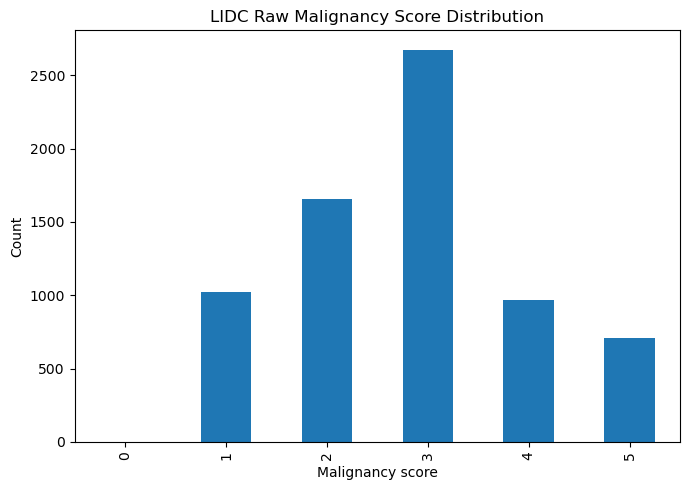

In [14]:
lidc_xml_nodules_df["malignancy"] = pd.to_numeric(
    lidc_xml_nodules_df["malignancy"],
    errors="coerce"
)

malignancy_counts = (
    lidc_xml_nodules_df["malignancy"]
    .value_counts(dropna=False)
    .sort_index()
)

print("Malignancy score distribution:")
print(malignancy_counts)

malignancy_counts.to_csv(
    TABLE_DIR / "lidc_malignancy_score_distribution.csv",
    header=["count"]
)

plt.figure(figsize=(7, 5))
lidc_xml_nodules_df["malignancy"].dropna().astype(int).value_counts().sort_index().plot(kind="bar")
plt.xlabel("Malignancy score")
plt.ylabel("Count")
plt.title("LIDC Raw Malignancy Score Distribution")
plt.tight_layout()
plt.savefig(FIGURE_DIR / "lidc_malignancy_score_distribution.png", dpi=300)
plt.show()


In [15]:
xml_series = set(
    lidc_xml_nodules_df["SeriesInstanceUID"]
    .dropna()
    .astype(str)
    .unique()
)

main_dicom_series = set(
    main_ct_series_df["SeriesInstanceUID"]
    .dropna()
    .astype(str)
    .unique()
)

all_dicom_ct_series = set(
    lidc_series_df.loc[lidc_series_df["Modality"] == "CT", "SeriesInstanceUID"]
    .dropna()
    .astype(str)
    .unique()
)

matched_main_series = xml_series.intersection(main_dicom_series)
matched_all_ct_series = xml_series.intersection(all_dicom_ct_series)

print("XML series count:", len(xml_series))
print("Main DICOM CT series count:", len(main_dicom_series))
print("All DICOM CT series count:", len(all_dicom_ct_series))
print("Matched XML to main CT series count:", len(matched_main_series))
print("Matched XML to any CT series count:", len(matched_all_ct_series))

print("Main CT match rate:", len(matched_main_series) / len(xml_series) if len(xml_series) > 0 else "N/A")
print("All CT match rate:", len(matched_all_ct_series) / len(xml_series) if len(xml_series) > 0 else "N/A")


XML series count: 998
Main DICOM CT series count: 1010
All DICOM CT series count: 1018
Matched XML to main CT series count: 990
Matched XML to any CT series count: 998
Main CT match rate: 0.9919839679358717
All CT match rate: 1.0


In [16]:
match_summary = pd.DataFrame([
    {
        "xml_series_count": len(xml_series),
        "main_dicom_ct_series_count": len(main_dicom_series),
        "all_dicom_ct_series_count": len(all_dicom_ct_series),
        "matched_main_ct_series_count": len(matched_main_series),
        "matched_all_ct_series_count": len(matched_all_ct_series),
        "main_ct_match_rate": len(matched_main_series) / len(xml_series) if len(xml_series) > 0 else np.nan,
        "all_ct_match_rate": len(matched_all_ct_series) / len(xml_series) if len(xml_series) > 0 else np.nan,
    }
])

match_summary.to_csv(TABLE_DIR / "lidc_xml_dicom_match_summary.csv", index=False)

display(match_summary)


,xml_series_count,main_dicom_ct_series_count,all_dicom_ct_series_count,matched_main_ct_series_count,matched_all_ct_series_count,main_ct_match_rate,all_ct_match_rate
0,998,1010,1018,990,998,0.991984,1.0


,reader_id,nodule_annotation_count
0,1,4964
1,2,4705
2,3,5608
3,4,5078
4,5,2
5,6,2
6,7,2
7,8,1


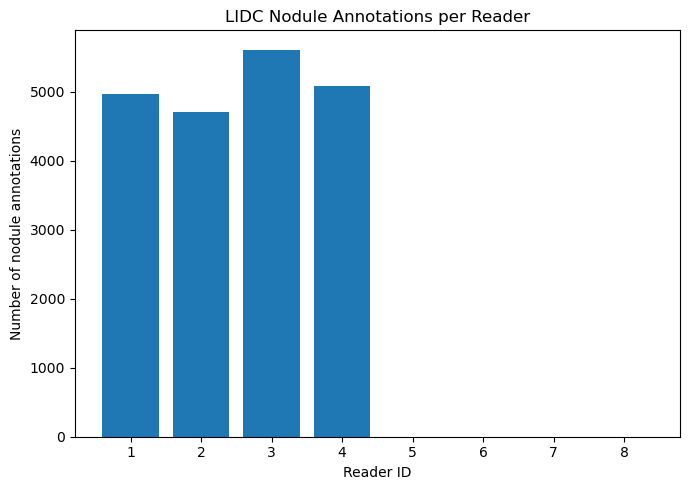

In [17]:
reader_counts = (
    lidc_xml_nodules_df
    .groupby("reader_id")
    .size()
    .reset_index(name="nodule_annotation_count")
)

display(reader_counts)

reader_counts.to_csv(TABLE_DIR / "lidc_reader_annotation_counts.csv", index=False)

plt.figure(figsize=(7, 5))
plt.bar(reader_counts["reader_id"], reader_counts["nodule_annotation_count"])
plt.xlabel("Reader ID")
plt.ylabel("Number of nodule annotations")
plt.title("LIDC Nodule Annotations per Reader")
plt.tight_layout()
plt.savefig(FIGURE_DIR / "lidc_reader_annotation_counts.png", dpi=300)
plt.show()


count    20362.000000
mean        86.906885
std        269.554030
min          1.000000
25%          1.000000
50%          1.000000
75%         69.000000
max       6814.000000
Name: edge_point_count, dtype: float64


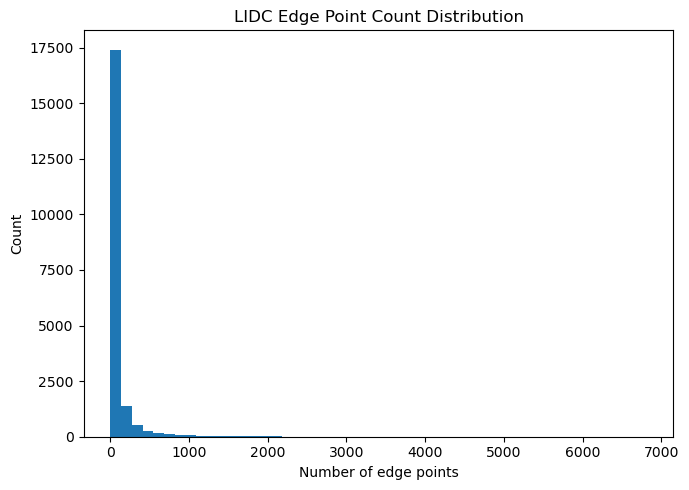

In [18]:
print(lidc_xml_nodules_df["edge_point_count"].describe())

plt.figure(figsize=(7, 5))
plt.hist(lidc_xml_nodules_df["edge_point_count"].dropna(), bins=50)
plt.xlabel("Number of edge points")
plt.ylabel("Count")
plt.title("LIDC Edge Point Count Distribution")
plt.tight_layout()
plt.savefig(FIGURE_DIR / "lidc_edge_point_count_distribution.png", dpi=300)
plt.show()


## Additional Requirement Coverage

The previous cells build a DICOM/XML inventory and inspect raw reader annotations. The following cells add the missing analyses required for: patient age/gender availability, nodule size/location/morphology distributions, and multi-reader annotation consistency across the four LIDC radiologists.


Building LIDC demographics table:   0%|          | 0/1010 [00:00<?, ?it/s]

Building LIDC demographics table:   0%|          | 1/1010 [00:00<11:10,  1.50it/s]

Building LIDC demographics table:   0%|          | 2/1010 [00:01<12:21,  1.36it/s]

Building LIDC demographics table:   0%|          | 3/1010 [00:02<12:53,  1.30it/s]

Building LIDC demographics table:   0%|          | 4/1010 [00:03<12:47,  1.31it/s]

...

Building LIDC demographics table:  97%|█████████▋| 981/1010 [02:54<00:00, 148.52it/s]

Building LIDC demographics table: 100%|██████████| 1010/1010 [02:56<00:00,  5.71it/s]

Patient demographics table shape: (1010, 12)


,patient_folder,PatientID,SeriesInstanceUID,PatientAge_raw,PatientAge_years,PatientAge_source,PatientSex_raw,PatientSex,PatientSex_source,ct_series_count,max_image_count,demographics_series_dir
0,LIDC-IDRI-0001,LIDC-IDRI-0001,1.3.6.1.4.1.14519.5.2.1.6279.6001.179049373636...,NaN,NaN,NaN,NaN,NaN,NaN,1,133,F:\AstraZeneca\project\chestCT\CHEST_CT_NSCLC\...
1,LIDC-IDRI-0002,LIDC-IDRI-0002,1.3.6.1.4.1.14519.5.2.1.6279.6001.619372068417...,NaN,NaN,NaN,NaN,NaN,NaN,1,261,F:\AstraZeneca\project\chestCT\CHEST_CT_NSCLC\...
2,LIDC-IDRI-0003,LIDC-IDRI-0003,1.3.6.1.4.1.14519.5.2.1.6279.6001.170706757615...,NaN,NaN,NaN,NaN,NaN,NaN,1,140,F:\AstraZeneca\project\chestCT\CHEST_CT_NSCLC\...
3,LIDC-IDRI-0004,LIDC-IDRI-0004,1.3.6.1.4.1.14519.5.2.1.6279.6001.323541312620...,NaN,NaN,NaN,NaN,NaN,NaN,1,241,F:\AstraZeneca\project\chestCT\CHEST_CT_NSCLC\...
4,LIDC-IDRI-0005,LIDC-IDRI-0005,1.3.6.1.4.1.14519.5.2.1.6279.6001.129007566048...,NaN,NaN,NaN,NaN,NaN,NaN,1,133,F:\AstraZeneca\project\chestCT\CHEST_CT_NSCLC\...


,field,available_count,missing_count,available_fraction
0,PatientAge_years,207,803,0.204950
1,PatientSex,286,724,0.283168


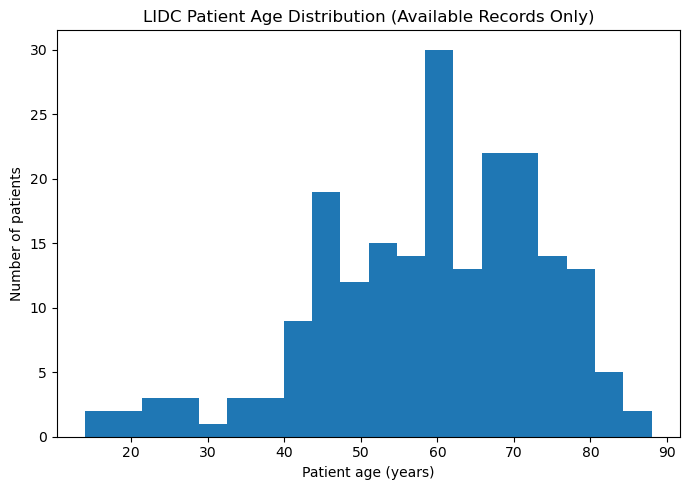

,PatientSex,count
0,NaN,724
1,F,146
2,M,140


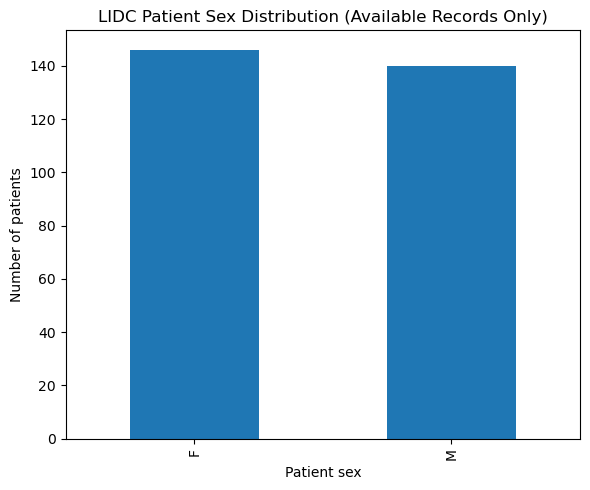

In [19]:
# Extra helpers used by the added exploratory analysis cells.
import ast
import re
from itertools import combinations


def parse_patient_age_to_years(value):
    """Convert DICOM age strings such as 063Y or 018M to years."""
    if pd.isna(value):
        return np.nan

    text = str(value).strip()
    if text == "":
        return np.nan

    match = re.match(r"^(\d+(?:\.\d+)?)([YMWD]?)$", text)
    if not match:
        return np.nan

    amount = float(match.group(1))
    unit = match.group(2) or "Y"

    if unit == "Y":
        return amount
    if unit == "M":
        return amount / 12
    if unit == "W":
        return amount / 52.1775
    if unit == "D":
        return amount / 365.25

    return np.nan


def clean_patient_sex(value):
    if pd.isna(value):
        return np.nan

    text = str(value).strip().upper()
    if text in {"M", "F", "O"}:
        return text

    return np.nan


def first_non_empty_mode(values):
    """Return the most frequent non-empty value in a patient-level group."""
    cleaned = [str(v).strip() for v in values if not pd.isna(v) and str(v).strip() != ""]
    if len(cleaned) == 0:
        return np.nan

    counts = pd.Series(cleaned).value_counts()
    return counts.index[0]


def metadata_series_dir(file_location):
    if pd.isna(file_location):
        return None

    rel = str(file_location).strip().replace("\\", "/")
    if rel.startswith("./"):
        rel = rel[2:]

    return LIDC_MANIFEST_ROOT / rel


def read_first_dicom_in_series(series_dir):
    if series_dir is None or not Path(series_dir).exists():
        return None

    for file_path in Path(series_dir).glob("*"):
        if not file_path.is_file():
            continue

        try:
            return pydicom.dcmread(str(file_path), stop_before_pixels=True, force=True)
        except Exception:
            continue

    return None


# Rebuild this table each run because the first version used only the selected main CT series.
# The corrected version aggregates age/sex across all CT series in the NBIA digest, then uses
# DICOM headers as a fallback when the digest is unavailable or incomplete.
lidc_demographics_path = TABLE_DIR / "lidc_patient_demographics.csv"
nbia_digest_path = LIDC_ROOT / "TCIA_LIDC-IDRI_20200921-nbia-digest.xlsx"

patient_index_df = pd.DataFrame({"patient_folder": sorted(main_ct_series_df["patient_folder"].dropna().unique())})

demographics_records = []

if nbia_digest_path.exists():
    nbia_metadata = pd.read_excel(nbia_digest_path, sheet_name="Metadata")
    nbia_ct = nbia_metadata[nbia_metadata["Modality"] == "CT"].copy()

    # Patient Age and Patient Sex in public LIDC are partly de-identified, so keep source fields.
    nbia_patient_demo = (
        nbia_ct
        .groupby("Patient ID")
        .agg(
            PatientAge_raw=("Patient Age", first_non_empty_mode),
            PatientSex_raw=("Patient Sex", first_non_empty_mode),
            ct_series_count=("Series Instance UID", "nunique"),
            max_image_count=("Image Count", "max"),
        )
        .reset_index()
        .rename(columns={"Patient ID": "patient_folder"})
    )
else:
    print("NBIA digest not found; demographics will be estimated from local DICOM headers only.")
    nbia_patient_demo = patient_index_df.copy()
    nbia_patient_demo["PatientAge_raw"] = np.nan
    nbia_patient_demo["PatientSex_raw"] = np.nan
    nbia_patient_demo["ct_series_count"] = np.nan
    nbia_patient_demo["max_image_count"] = np.nan

metadata_ct = lidc_metadata[lidc_metadata["Modality"] == "CT"].copy()
metadata_ct = metadata_ct.rename(
    columns={
        "Subject ID": "patient_folder",
        "Series UID": "SeriesInstanceUID",
        "File Location": "metadata_file_location",
    }
)

# Pick one metadata row per patient as a lightweight DICOM fallback for missing age/sex.
dicom_fallback_source = (
    metadata_ct
    .sort_values(["patient_folder", "Number of Images"], ascending=[True, False])
    .drop_duplicates("patient_folder")
    [["patient_folder", "SeriesInstanceUID", "metadata_file_location"]]
)

combined_demo = (
    patient_index_df
    .merge(nbia_patient_demo, on="patient_folder", how="left")
    .merge(dicom_fallback_source, on="patient_folder", how="left")
)

for row in tqdm(
    combined_demo.itertuples(index=False),
    total=len(combined_demo),
    desc="Building LIDC demographics table"
):
    age_raw = getattr(row, "PatientAge_raw", np.nan)
    sex_raw = getattr(row, "PatientSex_raw", np.nan)
    age_source = "NBIA digest" if not pd.isna(age_raw) and str(age_raw).strip() != "" else np.nan
    sex_source = "NBIA digest" if not pd.isna(sex_raw) and str(sex_raw).strip() != "" else np.nan

    # Only read DICOM if at least one demographic field is still missing.
    if pd.isna(age_source) or pd.isna(sex_source):
        series_dir = metadata_series_dir(getattr(row, "metadata_file_location", np.nan))
        ds = read_first_dicom_in_series(series_dir)

        if ds is not None:
            dicom_age = getattr(ds, "PatientAge", np.nan)
            dicom_sex = getattr(ds, "PatientSex", np.nan)

            if pd.isna(age_source) and not pd.isna(dicom_age) and str(dicom_age).strip() != "":
                age_raw = dicom_age
                age_source = "DICOM fallback"

            if pd.isna(sex_source) and not pd.isna(dicom_sex) and str(dicom_sex).strip() != "":
                sex_raw = dicom_sex
                sex_source = "DICOM fallback"
    else:
        series_dir = metadata_series_dir(getattr(row, "metadata_file_location", np.nan))

    demographics_records.append({
        "patient_folder": row.patient_folder,
        "PatientID": row.patient_folder,
        "SeriesInstanceUID": getattr(row, "SeriesInstanceUID", np.nan),
        "PatientAge_raw": age_raw,
        "PatientAge_years": parse_patient_age_to_years(age_raw),
        "PatientAge_source": age_source,
        "PatientSex_raw": sex_raw,
        "PatientSex": clean_patient_sex(sex_raw),
        "PatientSex_source": sex_source,
        "ct_series_count": getattr(row, "ct_series_count", np.nan),
        "max_image_count": getattr(row, "max_image_count", np.nan),
        "demographics_series_dir": str(series_dir) if series_dir is not None else np.nan,
    })

lidc_patient_demographics_df = pd.DataFrame(demographics_records)
lidc_patient_demographics_df.to_csv(lidc_demographics_path, index=False)

print("Patient demographics table shape:", lidc_patient_demographics_df.shape)
display(lidc_patient_demographics_df.head())

# Report missingness explicitly because most public LIDC records still do not expose age/sex.
missing_summary = pd.DataFrame([
    {
        "field": "PatientAge_years",
        "available_count": int(lidc_patient_demographics_df["PatientAge_years"].notna().sum()),
        "missing_count": int(lidc_patient_demographics_df["PatientAge_years"].isna().sum()),
        "available_fraction": lidc_patient_demographics_df["PatientAge_years"].notna().mean(),
    },
    {
        "field": "PatientSex",
        "available_count": int(lidc_patient_demographics_df["PatientSex"].notna().sum()),
        "missing_count": int(lidc_patient_demographics_df["PatientSex"].isna().sum()),
        "available_fraction": lidc_patient_demographics_df["PatientSex"].notna().mean(),
    },
])

missing_summary.to_csv(TABLE_DIR / "lidc_patient_demographics_missingness.csv", index=False)
display(missing_summary)

if lidc_patient_demographics_df["PatientAge_years"].notna().any():
    plt.figure(figsize=(7, 5))
    plt.hist(lidc_patient_demographics_df["PatientAge_years"].dropna(), bins=20)
    plt.xlabel("Patient age (years)")
    plt.ylabel("Number of patients")
    plt.title("LIDC Patient Age Distribution (Available Records Only)")
    plt.tight_layout()
    plt.savefig(FIGURE_DIR / "lidc_patient_age_distribution.png", dpi=300)
    plt.show()
else:
    print("Patient age is not available in the local LIDC DICOM headers/metadata; distribution cannot be estimated from this release.")

sex_counts = lidc_patient_demographics_df["PatientSex"].value_counts(dropna=False).rename_axis("PatientSex").reset_index(name="count")
sex_counts.to_csv(TABLE_DIR / "lidc_patient_sex_distribution.csv", index=False)
display(sex_counts)

if lidc_patient_demographics_df["PatientSex"].notna().any():
    plt.figure(figsize=(6, 5))
    lidc_patient_demographics_df["PatientSex"].dropna().value_counts().plot(kind="bar")
    plt.xlabel("Patient sex")
    plt.ylabel("Number of patients")
    plt.title("LIDC Patient Sex Distribution (Available Records Only)")
    plt.tight_layout()
    plt.savefig(FIGURE_DIR / "lidc_patient_sex_distribution.png", dpi=300)
    plt.show()
else:
    print("Patient sex is not available in the local LIDC DICOM headers/metadata; only missingness is reported.")


In [20]:
# Convert the stored PixelSpacing text into numeric row/column spacing in millimetres.
def parse_pixel_spacing(value):
    if pd.isna(value):
        return (np.nan, np.nan)

    if isinstance(value, (list, tuple)) and len(value) >= 2:
        return (float(value[0]), float(value[1]))

    text = str(value).strip()
    if text == "" or text.lower() == "none":
        return (np.nan, np.nan)

    try:
        parsed = ast.literal_eval(text)
        if isinstance(parsed, (list, tuple)) and len(parsed) >= 2:
            return (float(parsed[0]), float(parsed[1]))
    except Exception:
        pass

    parts = re.findall(r"\d+(?:\.\d+)?", text)
    if len(parts) >= 2:
        return (float(parts[0]), float(parts[1]))

    return (np.nan, np.nan)


def nodule_size_category(diameter_mm):
    if pd.isna(diameter_mm):
        return np.nan
    if diameter_mm < 3:
        return "<3 mm"
    if diameter_mm < 6:
        return "3-<6 mm"
    if diameter_mm < 10:
        return "6-<10 mm"
    if diameter_mm < 30:
        return "10-<30 mm"
    return ">=30 mm"


# XML values arrive as strings; convert nodule scores and coordinates before analysis.
numeric_annotation_cols = [
    "malignancy", "subtlety", "internal_structure", "calcification",
    "sphericity", "margin", "lobulation", "spiculation", "texture",
    "roi_count", "edge_point_count", "z_min", "z_max", "x_min", "x_max", "y_min", "y_max"
]

lidc_nodule_features_df = lidc_xml_nodules_df.copy()

for col in numeric_annotation_cols:
    lidc_nodule_features_df[col] = pd.to_numeric(lidc_nodule_features_df[col], errors="coerce")

# Attach DICOM spacing from all CT series, not only the selected main CT series.
# This avoids false missing spacing for XML annotations linked to a non-main CT series.
series_spacing = lidc_series_df[lidc_series_df["Modality"] == "CT"][
    ["patient_folder", "PatientID", "SeriesInstanceUID", "Rows", "Columns", "SliceThickness", "PixelSpacing", "num_slices"]
].copy()
series_spacing = (
    series_spacing
    .sort_values(["SeriesInstanceUID", "num_slices"], ascending=[True, False])
    .drop_duplicates("SeriesInstanceUID")
)

spacing_values = series_spacing["PixelSpacing"].apply(parse_pixel_spacing)
series_spacing["y_spacing_mm"] = spacing_values.apply(lambda x: x[0])
series_spacing["x_spacing_mm"] = spacing_values.apply(lambda x: x[1])
series_spacing["SliceThickness"] = pd.to_numeric(series_spacing["SliceThickness"], errors="coerce")
series_spacing["Rows"] = pd.to_numeric(series_spacing["Rows"], errors="coerce")
series_spacing["Columns"] = pd.to_numeric(series_spacing["Columns"], errors="coerce")

lidc_nodule_features_df = lidc_nodule_features_df.merge(
    series_spacing,
    on="SeriesInstanceUID",
    how="left"
)

# Derive annotation centroids in pixel/Z coordinates.
lidc_nodule_features_df["x_center_px"] = (lidc_nodule_features_df["x_min"] + lidc_nodule_features_df["x_max"]) / 2
lidc_nodule_features_df["y_center_px"] = (lidc_nodule_features_df["y_min"] + lidc_nodule_features_df["y_max"]) / 2
lidc_nodule_features_df["z_center_mm"] = (lidc_nodule_features_df["z_min"] + lidc_nodule_features_df["z_max"]) / 2

# Convert image-plane bounding boxes from pixels to millimetres.
lidc_nodule_features_df["x_min_mm"] = lidc_nodule_features_df["x_min"] * lidc_nodule_features_df["x_spacing_mm"]
lidc_nodule_features_df["x_max_mm"] = lidc_nodule_features_df["x_max"] * lidc_nodule_features_df["x_spacing_mm"]
lidc_nodule_features_df["y_min_mm"] = lidc_nodule_features_df["y_min"] * lidc_nodule_features_df["y_spacing_mm"]
lidc_nodule_features_df["y_max_mm"] = lidc_nodule_features_df["y_max"] * lidc_nodule_features_df["y_spacing_mm"]
lidc_nodule_features_df["x_center_mm"] = lidc_nodule_features_df["x_center_px"] * lidc_nodule_features_df["x_spacing_mm"]
lidc_nodule_features_df["y_center_mm"] = lidc_nodule_features_df["y_center_px"] * lidc_nodule_features_df["y_spacing_mm"]

# Approximate nodule size from the maximum extent across x, y, and z.
# Size is only considered valid when all three spacing components are available.
has_spacing = lidc_nodule_features_df[["x_spacing_mm", "y_spacing_mm", "SliceThickness"]].notna().all(axis=1)

lidc_nodule_features_df["x_diameter_mm"] = np.where(
    has_spacing,
    (lidc_nodule_features_df["x_max"] - lidc_nodule_features_df["x_min"] + 1) * lidc_nodule_features_df["x_spacing_mm"],
    np.nan
)
lidc_nodule_features_df["y_diameter_mm"] = np.where(
    has_spacing,
    (lidc_nodule_features_df["y_max"] - lidc_nodule_features_df["y_min"] + 1) * lidc_nodule_features_df["y_spacing_mm"],
    np.nan
)
lidc_nodule_features_df["z_diameter_mm"] = np.where(
    has_spacing,
    (lidc_nodule_features_df["z_max"] - lidc_nodule_features_df["z_min"]).abs() + lidc_nodule_features_df["SliceThickness"],
    np.nan
)

lidc_nodule_features_df["max_diameter_mm"] = lidc_nodule_features_df[
    ["x_diameter_mm", "y_diameter_mm", "z_diameter_mm"]
].max(axis=1)
lidc_nodule_features_df["size_category"] = lidc_nodule_features_df["max_diameter_mm"].apply(nodule_size_category)

# Approximate nodule location using image halves and z-tertiles.
lidc_nodule_features_df["image_side"] = np.where(
    lidc_nodule_features_df["x_center_px"] < (lidc_nodule_features_df["Columns"].fillna(512) / 2),
    "image_left",
    "image_right"
)
lidc_nodule_features_df.loc[lidc_nodule_features_df["x_center_px"].isna() | lidc_nodule_features_df["Columns"].isna(), "image_side"] = np.nan

lidc_nodule_features_df["image_ap_position"] = np.where(
    lidc_nodule_features_df["y_center_px"] < (lidc_nodule_features_df["Rows"].fillna(512) / 2),
    "anterior_half",
    "posterior_half"
)
lidc_nodule_features_df.loc[lidc_nodule_features_df["y_center_px"].isna() | lidc_nodule_features_df["Rows"].isna(), "image_ap_position"] = np.nan

valid_z = lidc_nodule_features_df["z_center_mm"].dropna()
if valid_z.nunique() >= 3:
    lidc_nodule_features_df["z_location_tertile"] = pd.qcut(
        lidc_nodule_features_df["z_center_mm"],
        q=3,
        labels=["lower_z_third", "middle_z_third", "upper_z_third"],
        duplicates="drop"
    )
else:
    lidc_nodule_features_df["z_location_tertile"] = np.nan

lidc_nodule_features_path = TABLE_DIR / "lidc_nodule_size_location_morphology.csv"
lidc_nodule_features_df.to_csv(lidc_nodule_features_path, index=False)

print("Nodule feature table shape:", lidc_nodule_features_df.shape)
print("Saved to:", lidc_nodule_features_path)
print("Annotations missing CT spacing after all-series join:", int(lidc_nodule_features_df["max_diameter_mm"].isna().sum()))
display(lidc_nodule_features_df.head())


Nodule feature table shape: (20362, 49)
Saved to: F:\AstraZeneca\project\chestCT\CHEST_CT_NSCLC\data\processed\tables\lidc_nodule_size_location_morphology.csv
Annotations missing CT spacing after all-series join: 0


,xml_file,xml_name,StudyInstanceUID,SeriesInstanceUID,reader_id,nodule_id,malignancy,subtlety,internal_structure,calcification,...,x_center_mm,y_center_mm,x_diameter_mm,y_diameter_mm,z_diameter_mm,max_diameter_mm,size_category,image_side,image_ap_position,z_location_tertile
0,F:\AstraZeneca\project\chestCT\CHEST_CT_NSCLC\...,158.xml,1.3.6.1.4.1.14519.5.2.1.6279.6001.339170810277...,1.3.6.1.4.1.14519.5.2.1.6279.6001.303494235102...,1,0,NaN,NaN,NaN,NaN,...,115.050,229.450,0.65,0.65,3.0,3.0,3-<6 mm,image_left,posterior_half,upper_z_third
1,F:\AstraZeneca\project\chestCT\CHEST_CT_NSCLC\...,158.xml,1.3.6.1.4.1.14519.5.2.1.6279.6001.339170810277...,1.3.6.1.4.1.14519.5.2.1.6279.6001.303494235102...,1,3,3.0,5.0,1.0,6.0,...,235.300,108.875,17.55,22.10,18.0,22.1,10-<30 mm,image_right,anterior_half,upper_z_third
2,F:\AstraZeneca\project\chestCT\CHEST_CT_NSCLC\...,158.xml,1.3.6.1.4.1.14519.5.2.1.6279.6001.339170810277...,1.3.6.1.4.1.14519.5.2.1.6279.6001.303494235102...,1,4,3.0,4.0,1.0,6.0,...,215.475,203.450,18.20,17.55,18.0,18.2,10-<30 mm,image_right,posterior_half,upper_z_third
3,F:\AstraZeneca\project\chestCT\CHEST_CT_NSCLC\...,158.xml,1.3.6.1.4.1.14519.5.2.1.6279.6001.339170810277...,1.3.6.1.4.1.14519.5.2.1.6279.6001.303494235102...,1,5,NaN,NaN,NaN,NaN,...,128.050,208.650,0.65,0.65,3.0,3.0,3-<6 mm,image_left,posterior_half,upper_z_third
4,F:\AstraZeneca\project\chestCT\CHEST_CT_NSCLC\...,158.xml,1.3.6.1.4.1.14519.5.2.1.6279.6001.339170810277...,1.3.6.1.4.1.14519.5.2.1.6279.6001.303494235102...,1,6,4.0,5.0,1.0,4.0,...,222.950,159.250,22.75,22.75,24.0,24.0,10-<30 mm,image_right,anterior_half,upper_z_third


,size_category,annotation_count
0,<3 mm,11702
1,6-<10 mm,3374
2,10-<30 mm,2708
3,3-<6 mm,2255
4,>=30 mm,323


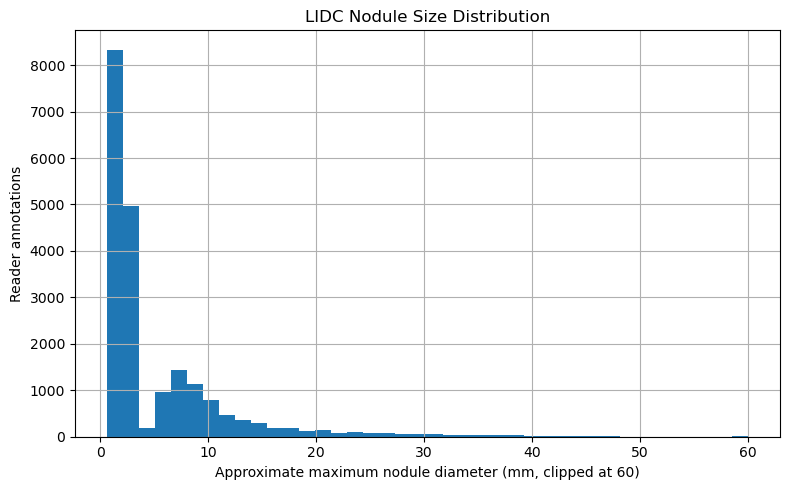

C:\Users\Ambro\AppData\Local\Temp\ipykernel_46068\1196698758.py:22: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  lidc_nodule_features_df


,image_side,image_ap_position,z_location_tertile,annotation_count
5,image_left,posterior_half,upper_z_third,2475
3,image_left,posterior_half,lower_z_third,2413
9,image_right,posterior_half,lower_z_third,2145
4,image_left,posterior_half,middle_z_third,2143
11,image_right,posterior_half,upper_z_third,1984
1,image_left,anterior_half,middle_z_third,1884
10,image_right,posterior_half,middle_z_third,1717
0,image_left,anterior_half,lower_z_third,1349
2,image_left,anterior_half,upper_z_third,1267
7,image_right,anterior_half,middle_z_third,1052


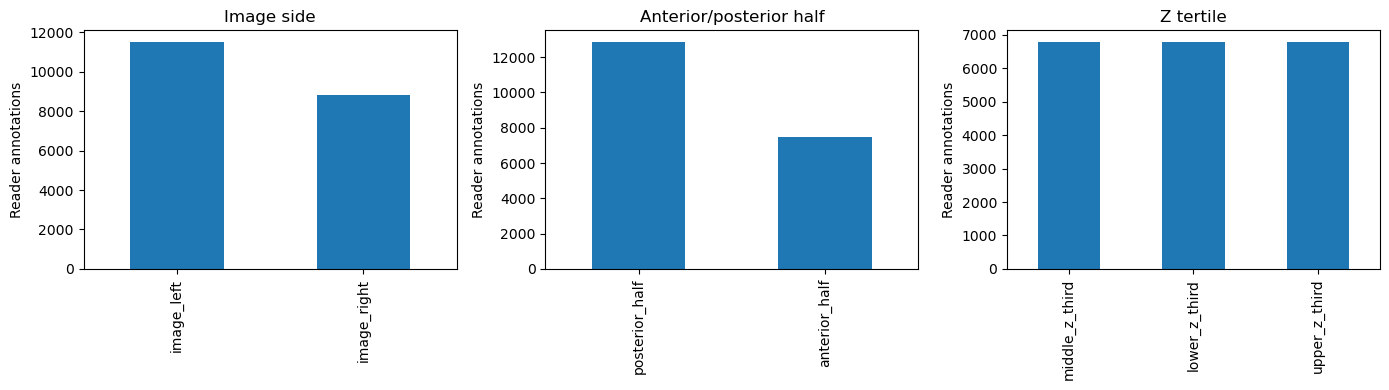

,feature,score,annotation_count
0,subtlety,0.0,2
1,subtlety,1.0,411
2,subtlety,2.0,652
3,subtlety,3.0,1470
4,subtlety,4.0,1914
5,subtlety,5.0,2583
6,subtlety,NaN,13330
7,internal_structure,0.0,2
8,internal_structure,1.0,6981
9,internal_structure,2.0,11


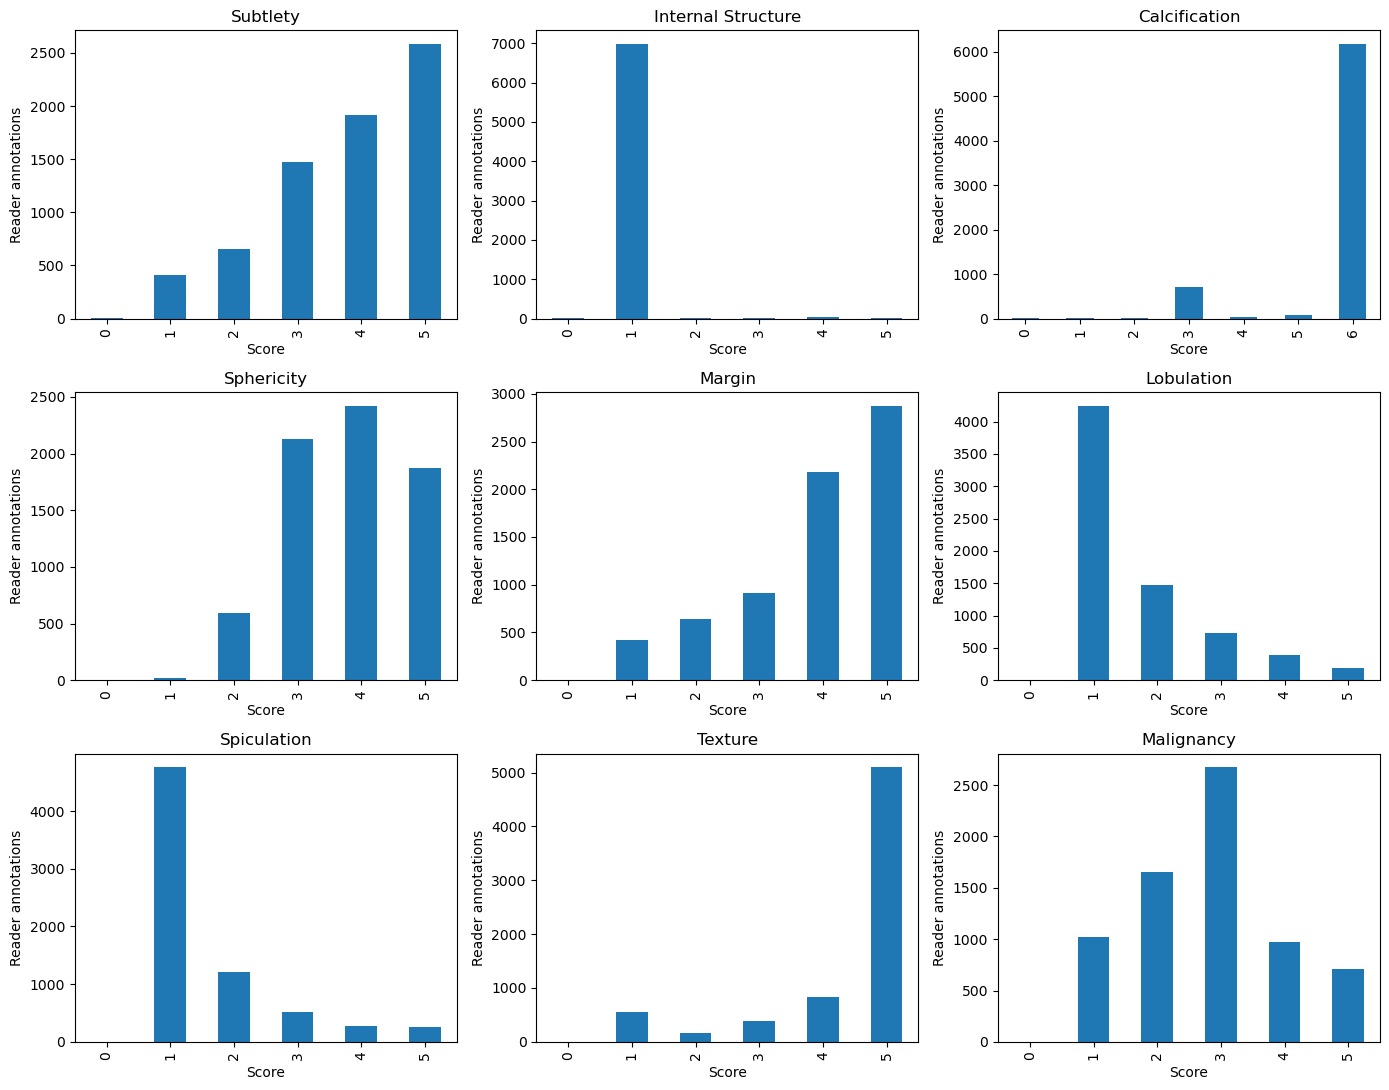

In [21]:
# Summarise the approximate nodule size distribution.
size_distribution = (
    lidc_nodule_features_df["size_category"]
    .value_counts(dropna=False)
    .rename_axis("size_category")
    .reset_index(name="annotation_count")
)
size_distribution.to_csv(TABLE_DIR / "lidc_nodule_size_category_distribution.csv", index=False)
display(size_distribution)

plt.figure(figsize=(8, 5))
lidc_nodule_features_df["max_diameter_mm"].dropna().clip(upper=60).hist(bins=40)
plt.xlabel("Approximate maximum nodule diameter (mm, clipped at 60)")
plt.ylabel("Reader annotations")
plt.title("LIDC Nodule Size Distribution")
plt.tight_layout()
plt.savefig(FIGURE_DIR / "lidc_nodule_size_distribution.png", dpi=300)
plt.show()

# Summarise coarse spatial location categories.
location_distribution = (
    lidc_nodule_features_df
    .groupby(["image_side", "image_ap_position", "z_location_tertile"], dropna=False)
    .size()
    .reset_index(name="annotation_count")
    .sort_values("annotation_count", ascending=False)
)
location_distribution.to_csv(TABLE_DIR / "lidc_nodule_location_distribution.csv", index=False)
display(location_distribution.head(20))

fig, axes = plt.subplots(1, 3, figsize=(14, 4))
lidc_nodule_features_df["image_side"].value_counts(dropna=False).plot(kind="bar", ax=axes[0], title="Image side")
lidc_nodule_features_df["image_ap_position"].value_counts(dropna=False).plot(kind="bar", ax=axes[1], title="Anterior/posterior half")
lidc_nodule_features_df["z_location_tertile"].value_counts(dropna=False).plot(kind="bar", ax=axes[2], title="Z tertile")
for ax in axes:
    ax.set_xlabel("")
    ax.set_ylabel("Reader annotations")
plt.tight_layout()
plt.savefig(FIGURE_DIR / "lidc_nodule_location_distribution.png", dpi=300)
plt.show()

# Summarise the LIDC ordinal morphology scores recorded by readers.
morphology_cols = [
    "subtlety", "internal_structure", "calcification", "sphericity",
    "margin", "lobulation", "spiculation", "texture", "malignancy"
]

morphology_summary = []
for col in morphology_cols:
    counts = lidc_nodule_features_df[col].value_counts(dropna=False).sort_index()
    for score, count in counts.items():
        morphology_summary.append({"feature": col, "score": score, "annotation_count": int(count)})

morphology_summary_df = pd.DataFrame(morphology_summary)
morphology_summary_df.to_csv(TABLE_DIR / "lidc_nodule_morphology_score_distributions.csv", index=False)
display(morphology_summary_df.head(30))

fig, axes = plt.subplots(3, 3, figsize=(14, 11))
for ax, col in zip(axes.ravel(), morphology_cols):
    lidc_nodule_features_df[col].dropna().astype(int).value_counts().sort_index().plot(kind="bar", ax=ax)
    ax.set_title(col.replace("_", " ").title())
    ax.set_xlabel("Score")
    ax.set_ylabel("Reader annotations")
plt.tight_layout()
plt.savefig(FIGURE_DIR / "lidc_nodule_morphology_distributions.png", dpi=300)
plt.show()


In [22]:
# Spatial clustering helpers: used to link different readers' marks that likely describe the same lesion.
def interval_overlap(min_a, max_a, min_b, max_b):
    return max(0.0, min(max_a, max_b) - max(min_a, min_b))


def bbox_iou_3d(row_a, row_b):
    x_overlap = interval_overlap(row_a.x_min_mm, row_a.x_max_mm, row_b.x_min_mm, row_b.x_max_mm)
    y_overlap = interval_overlap(row_a.y_min_mm, row_a.y_max_mm, row_b.y_min_mm, row_b.y_max_mm)
    z_overlap = interval_overlap(row_a.z_min, row_a.z_max, row_b.z_min, row_b.z_max)

    intersection = x_overlap * y_overlap * z_overlap

    volume_a = max(0.0, row_a.x_max_mm - row_a.x_min_mm) * max(0.0, row_a.y_max_mm - row_a.y_min_mm) * max(0.0, row_a.z_max - row_a.z_min)
    volume_b = max(0.0, row_b.x_max_mm - row_b.x_min_mm) * max(0.0, row_b.y_max_mm - row_b.y_min_mm) * max(0.0, row_b.z_max - row_b.z_min)
    union = volume_a + volume_b - intersection

    if union <= 0:
        return 0.0

    return intersection / union


def centroid_distance_mm(row_a, row_b):
    return float(np.sqrt(
        (row_a.x_center_mm - row_b.x_center_mm) ** 2
        + (row_a.y_center_mm - row_b.y_center_mm) ** 2
        + (row_a.z_center_mm - row_b.z_center_mm) ** 2
    ))


# Two annotations are considered the same lesion if readers differ and spatial overlap/proximity is sufficient.
# The distance threshold is intentionally stricter for tiny single-point nodules to reduce false merging.
def same_lesion_candidate(row_a, row_b):
    if row_a.reader_id == row_b.reader_id:
        return False

    distance = centroid_distance_mm(row_a, row_b)
    mean_diameter = np.nanmean([row_a.max_diameter_mm, row_b.max_diameter_mm])
    distance_threshold = min(10.0, max(3.0, 0.5 * mean_diameter + 2.0)) if not np.isnan(mean_diameter) else 3.0
    iou = bbox_iou_3d(row_a, row_b)

    return (iou >= 0.10) or (distance <= distance_threshold)


def connected_components_for_series(group):
    indices = group.index.to_list()
    reader_lookup = group["reader_id"].to_dict()
    parent = {idx: idx for idx in indices}
    component_readers = {idx: {reader_lookup[idx]} for idx in indices}

    def find(idx):
        while parent[idx] != idx:
            parent[idx] = parent[parent[idx]]
            idx = parent[idx]
        return idx

    def union(a, b):
        root_a = find(a)
        root_b = find(b)
        if root_a == root_b:
            return

        # A physical lesion should have at most one annotation per reader. This prevents
        # transitive over-merging of nearby separate nodules into clusters with >4 marks.
        if component_readers[root_a].intersection(component_readers[root_b]):
            return

        parent[root_b] = root_a
        component_readers[root_a] = component_readers[root_a].union(component_readers[root_b])

    records = list(group.itertuples())
    for row_a, row_b in combinations(records, 2):
        if same_lesion_candidate(row_a, row_b):
            union(row_a.Index, row_b.Index)

    roots = {idx: find(idx) for idx in indices}
    root_to_number = {root: number for number, root in enumerate(sorted(set(roots.values())), start=1)}

    return pd.Series({idx: root_to_number[root] for idx, root in roots.items()})


# Only annotations with complete spatial coordinates can be clustered reliably.
clusterable_cols = [
    "SeriesInstanceUID", "reader_id", "x_min_mm", "x_max_mm", "y_min_mm", "y_max_mm",
    "z_min", "z_max", "x_center_mm", "y_center_mm", "z_center_mm", "max_diameter_mm"
]

clusterable_mask = lidc_nodule_features_df[clusterable_cols].notna().all(axis=1)
cluster_source_df = lidc_nodule_features_df[clusterable_mask].copy()

# Cluster annotations separately within each CT series to avoid mixing patients/scans.
cluster_assignments = []
for series_uid, group in tqdm(cluster_source_df.groupby("SeriesInstanceUID"), desc="Clustering reader annotations"):
    component_numbers = connected_components_for_series(group)
    assigned = pd.DataFrame({
        "index": component_numbers.index,
        "lesion_cluster_number": component_numbers.values,
    })
    assigned["lesion_cluster_id"] = assigned["lesion_cluster_number"].apply(
        lambda x: f"{series_uid}__cluster_{int(x):03d}"
    )
    cluster_assignments.append(assigned)

if cluster_assignments:
    cluster_assignment_df = pd.concat(cluster_assignments, ignore_index=True).set_index("index")
else:
    cluster_assignment_df = pd.DataFrame(columns=["lesion_cluster_number", "lesion_cluster_id"])

lidc_reader_clustered_df = lidc_nodule_features_df.join(cluster_assignment_df, how="left")
lidc_reader_clustered_df.to_csv(TABLE_DIR / "lidc_reader_annotations_clustered.csv", index=False)

print("Clustered annotation table shape:", lidc_reader_clustered_df.shape)
print("Clustered annotations:", int(lidc_reader_clustered_df["lesion_cluster_id"].notna().sum()))
display(lidc_reader_clustered_df[["SeriesInstanceUID", "reader_id", "nodule_id", "lesion_cluster_id", "max_diameter_mm"]].head())


Clustering reader annotations:   0%|          | 0/998 [00:00<?, ?it/s]

Clustering reader annotations:   1%|          | 9/998 [00:00<00:17, 58.11it/s]

Clustering reader annotations:   2%|▏         | 15/998 [00:00<00:18, 53.01it/s]

Clustering reader annotations:   3%|▎         | 25/998 [00:00<00:14, 66.98it/s]

Clustering reader annotations:   3%|▎         | 32/998 [00:00<00:25, 38.35it/s]

...

Clustering reader annotations:  99%|█████████▉| 987/998 [00:20<00:00, 36.92it/s]

Clustering reader annotations:  99%|█████████▉| 993/998 [00:21<00:00, 38.19it/s]

Clustering reader annotations: 100%|██████████| 998/998 [00:21<00:00, 46.96it/s]

Clustered annotation table shape: (20362, 51)
Clustered annotations: 20362


,SeriesInstanceUID,reader_id,nodule_id,lesion_cluster_id,max_diameter_mm
0,1.3.6.1.4.1.14519.5.2.1.6279.6001.303494235102...,1,0,1.3.6.1.4.1.14519.5.2.1.6279.6001.303494235102...,3.0
1,1.3.6.1.4.1.14519.5.2.1.6279.6001.303494235102...,1,3,1.3.6.1.4.1.14519.5.2.1.6279.6001.303494235102...,22.1
2,1.3.6.1.4.1.14519.5.2.1.6279.6001.303494235102...,1,4,1.3.6.1.4.1.14519.5.2.1.6279.6001.303494235102...,18.2
3,1.3.6.1.4.1.14519.5.2.1.6279.6001.303494235102...,1,5,1.3.6.1.4.1.14519.5.2.1.6279.6001.303494235102...,3.0
4,1.3.6.1.4.1.14519.5.2.1.6279.6001.303494235102...,1,6,1.3.6.1.4.1.14519.5.2.1.6279.6001.303494235102...,24.0


Annotation consistency table shape: (7490, 23)
Saved to: F:\AstraZeneca\project\chestCT\CHEST_CT_NSCLC\data\processed\tables\lidc_annotation_consistency_by_lesion_cluster.csv


,lesion_cluster_id,SeriesInstanceUID,patient_folder,annotation_count,reader_count,reader_ids,median_max_diameter_mm,diameter_range_mm,diameter_cv,max_centroid_distance_mm,...,malignancy_consistent,morphology_consistent,malignancy_range,sphericity_range,margin_range,lobulation_range,spiculation_range,texture_range,reader_agreement_category,overall_consistency
0,1.3.6.1.4.1.14519.5.2.1.6279.6001.100225287222...,1.3.6.1.4.1.14519.5.2.1.6279.6001.100225287222...,LIDC-IDRI-1001,4,4,"1,2,3,4",7.089844,0.954688,0.049046,1.469734,...,False,False,2.0,2.0,1.0,0.0,0.0,0.0,4-reader consensus,moderate
1,1.3.6.1.4.1.14519.5.2.1.6279.6001.100225287222...,1.3.6.1.4.1.14519.5.2.1.6279.6001.100225287222...,LIDC-IDRI-1001,4,4,"1,2,3,4",5.478516,4.445312,0.311713,1.008816,...,False,False,2.0,1.0,2.0,1.0,1.0,1.0,4-reader consensus,moderate
2,1.3.6.1.4.1.14519.5.2.1.6279.6001.100225287222...,1.3.6.1.4.1.14519.5.2.1.6279.6001.100225287222...,LIDC-IDRI-1001,4,4,"1,2,3,4",2.000000,0.000000,0.000000,0.911505,...,True,True,NaN,NaN,NaN,NaN,NaN,NaN,4-reader consensus,high
3,1.3.6.1.4.1.14519.5.2.1.6279.6001.100225287222...,1.3.6.1.4.1.14519.5.2.1.6279.6001.100225287222...,LIDC-IDRI-1001,3,3,"1,2,3",2.000000,0.000000,0.000000,0.911505,...,True,True,NaN,NaN,NaN,NaN,NaN,NaN,3-reader majority,high
4,1.3.6.1.4.1.14519.5.2.1.6279.6001.100225287222...,1.3.6.1.4.1.14519.5.2.1.6279.6001.100225287222...,LIDC-IDRI-1001,2,2,"2,4",2.000000,0.000000,0.000000,0.644531,...,True,True,NaN,NaN,NaN,NaN,NaN,NaN,2-reader partial,moderate


,criterion,definition
0,Lesion matching,Annotations from different readers are linked ...
1,Reader agreement,Number of unique radiologists represented in e...
2,Centroid consistency,Maximum pairwise centroid distance within the ...
3,Size consistency,Maximum diameter range <= 5 mm or coefficient ...
4,Morphology consistency,Ordinal morphology score ranges are <= 1 point...
5,Malignancy consistency,Malignancy score range is <= 1 point for avail...
6,Overall consistency,"High: >=3 readers plus centroid, size and mali..."


,reader_agreement_category,lesion_cluster_count
0,4-reader consensus,2584
1,3-reader majority,1755
2,2-reader partial,1610
3,single-reader only,1541


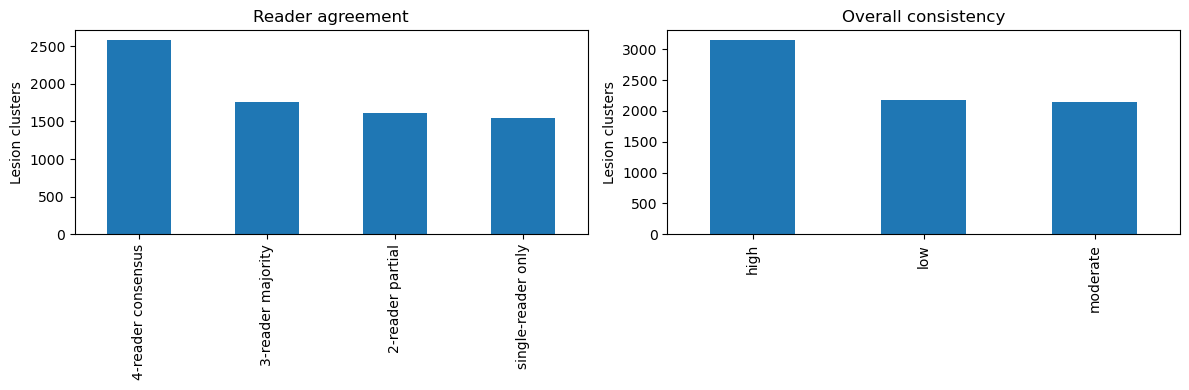

In [23]:
# Consistency helpers: smaller score/size/position ranges imply stronger reader agreement.
def score_range(series):
    values = series.dropna()
    if values.empty:
        return np.nan
    return values.max() - values.min()


def max_pairwise_centroid_distance(group):
    rows = list(group.dropna(subset=["x_center_mm", "y_center_mm", "z_center_mm"]).itertuples())
    if len(rows) < 2:
        return np.nan

    distances = [centroid_distance_mm(row_a, row_b) for row_a, row_b in combinations(rows, 2)]
    return max(distances) if distances else np.nan


# Create one consistency summary row for each clustered physical lesion.
def summarize_reader_cluster(group):
    morphology_ranges = {
        f"{col}_range": score_range(group[col])
        for col in ["malignancy", "sphericity", "margin", "lobulation", "spiculation", "texture"]
    }

    reader_count = group["reader_id"].nunique()
    median_diameter = group["max_diameter_mm"].median()
    diameter_range = score_range(group["max_diameter_mm"])
    diameter_cv = group["max_diameter_mm"].std(ddof=0) / median_diameter if median_diameter and not np.isnan(median_diameter) else np.nan
    max_centroid_distance = max_pairwise_centroid_distance(group)
    centroid_threshold = max(10.0, 0.5 * median_diameter) if not np.isnan(median_diameter) else 10.0

    result = {
        "SeriesInstanceUID": group["SeriesInstanceUID"].iloc[0],
        "patient_folder": group["patient_folder"].dropna().iloc[0] if group["patient_folder"].notna().any() else np.nan,
        "annotation_count": len(group),
        "reader_count": reader_count,
        "reader_ids": ",".join(map(str, sorted(group["reader_id"].dropna().astype(int).unique()))),
        "median_max_diameter_mm": median_diameter,
        "diameter_range_mm": diameter_range,
        "diameter_cv": diameter_cv,
        "max_centroid_distance_mm": max_centroid_distance,
        "centroid_threshold_mm": centroid_threshold,
        "centroid_consistent": bool(pd.isna(max_centroid_distance) or max_centroid_distance <= centroid_threshold),
        "size_consistent": bool(pd.isna(diameter_range) or diameter_range <= 5 or (not pd.isna(diameter_cv) and diameter_cv <= 0.25)),
        "malignancy_consistent": bool(pd.isna(morphology_ranges["malignancy_range"]) or morphology_ranges["malignancy_range"] <= 1),
        "morphology_consistent": bool(all(
            pd.isna(value) or value <= 1
            for key, value in morphology_ranges.items()
            if key != "malignancy_range"
        )),
    }

    result.update(morphology_ranges)
    return pd.Series(result)


clustered_valid_df = lidc_reader_clustered_df.dropna(subset=["lesion_cluster_id"]).copy()

lidc_annotation_consistency_df = (
    clustered_valid_df
    .groupby("lesion_cluster_id")
    .apply(summarize_reader_cluster, include_groups=False)
    .reset_index()
)

# Convert the number of unique readers into an interpretable agreement category.
conditions = [
    (lidc_annotation_consistency_df["reader_count"] == 4),
    (lidc_annotation_consistency_df["reader_count"] == 3),
    (lidc_annotation_consistency_df["reader_count"] == 2),
]
choices = ["4-reader consensus", "3-reader majority", "2-reader partial"]
lidc_annotation_consistency_df["reader_agreement_category"] = np.select(
    conditions,
    choices,
    default="single-reader only"
)

lidc_annotation_consistency_df["overall_consistency"] = np.select(
    [
        (lidc_annotation_consistency_df["reader_count"] >= 3)
        & lidc_annotation_consistency_df["centroid_consistent"]
        & lidc_annotation_consistency_df["size_consistent"]
        & lidc_annotation_consistency_df["malignancy_consistent"],
        (lidc_annotation_consistency_df["reader_count"] >= 2)
        & lidc_annotation_consistency_df["centroid_consistent"]
        & lidc_annotation_consistency_df["size_consistent"],
    ],
    ["high", "moderate"],
    default="low"
)

lidc_annotation_consistency_path = TABLE_DIR / "lidc_annotation_consistency_by_lesion_cluster.csv"
lidc_annotation_consistency_df.to_csv(lidc_annotation_consistency_path, index=False)

print("Annotation consistency table shape:", lidc_annotation_consistency_df.shape)
print("Saved to:", lidc_annotation_consistency_path)
display(lidc_annotation_consistency_df.head())

# Save the exact criteria so the analysis is transparent and reproducible.
criteria_summary = pd.DataFrame([
    {"criterion": "Lesion matching", "definition": "Annotations from different readers are linked when 3D bounding-box IoU >= 0.10 or centroid distance <= max(10 mm, half mean diameter)."},
    {"criterion": "Reader agreement", "definition": "Number of unique radiologists represented in each spatial lesion cluster: 1, 2, 3, or 4."},
    {"criterion": "Centroid consistency", "definition": "Maximum pairwise centroid distance within the cluster <= max(10 mm, half median diameter)."},
    {"criterion": "Size consistency", "definition": "Maximum diameter range <= 5 mm or coefficient of variation <= 0.25."},
    {"criterion": "Morphology consistency", "definition": "Ordinal morphology score ranges are <= 1 point for available reader scores."},
    {"criterion": "Malignancy consistency", "definition": "Malignancy score range is <= 1 point for available reader scores."},
    {"criterion": "Overall consistency", "definition": "High: >=3 readers plus centroid, size and malignancy consistency. Moderate: >=2 readers plus centroid and size consistency. Otherwise low."},
])
criteria_summary.to_csv(TABLE_DIR / "lidc_annotation_consistency_criteria.csv", index=False)
display(criteria_summary)

# Plot how often lesions have 1-, 2-, 3-, or 4-reader support.
agreement_counts = lidc_annotation_consistency_df["reader_agreement_category"].value_counts().rename_axis("reader_agreement_category").reset_index(name="lesion_cluster_count")
agreement_counts.to_csv(TABLE_DIR / "lidc_reader_agreement_distribution.csv", index=False)
display(agreement_counts)

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
lidc_annotation_consistency_df["reader_agreement_category"].value_counts().plot(kind="bar", ax=axes[0], title="Reader agreement")
lidc_annotation_consistency_df["overall_consistency"].value_counts().plot(kind="bar", ax=axes[1], title="Overall consistency")
for ax in axes:
    ax.set_xlabel("")
    ax.set_ylabel("Lesion clusters")
plt.tight_layout()
plt.savefig(FIGURE_DIR / "lidc_annotation_consistency_summary.png", dpi=300)
plt.show()


In [24]:
# Quality-control audit for downstream experiment risk.
# This table highlights missing metadata, unmatched XML series, invalid sizes, and possible clustering issues.
qc_rows = []

qc_rows.append({
    "check": "patient_age_available_fraction",
    "value": lidc_patient_demographics_df["PatientAge_years"].notna().mean(),
    "risk_level": "high" if lidc_patient_demographics_df["PatientAge_years"].notna().mean() < 0.8 else "low",
    "recommendation": "Do not use age as a primary covariate without missingness handling/sensitivity analysis.",
})
qc_rows.append({
    "check": "patient_sex_available_fraction",
    "value": lidc_patient_demographics_df["PatientSex"].notna().mean(),
    "risk_level": "high" if lidc_patient_demographics_df["PatientSex"].notna().mean() < 0.8 else "low",
    "recommendation": "Do not train/evaluate sex-stratified models on complete cases only without reporting bias.",
})
qc_rows.append({
    "check": "annotations_missing_spacing_fraction",
    "value": lidc_nodule_features_df["max_diameter_mm"].isna().mean(),
    "risk_level": "medium" if lidc_nodule_features_df["max_diameter_mm"].isna().any() else "low",
    "recommendation": "Exclude annotations without spacing from size/location experiments or recover the missing CT series.",
})
qc_rows.append({
    "check": "diameter_le_zero_count",
    "value": int((lidc_nodule_features_df["max_diameter_mm"] <= 0).sum()),
    "risk_level": "high" if (lidc_nodule_features_df["max_diameter_mm"] <= 0).any() else "low",
    "recommendation": "Zero/negative diameters should be excluded from modelling and investigated.",
})
qc_rows.append({
    "check": "diameter_gt_60mm_count",
    "value": int((lidc_nodule_features_df["max_diameter_mm"] > 60).sum()),
    "risk_level": "medium" if (lidc_nodule_features_df["max_diameter_mm"] > 60).any() else "low",
    "recommendation": "Very large lesions may be masses or annotation artefacts; review before using nodule-size bins.",
})
qc_rows.append({
    "check": "morphology_available_fraction",
    "value": lidc_nodule_features_df["malignancy"].notna().mean(),
    "risk_level": "medium" if lidc_nodule_features_df["malignancy"].notna().mean() < 0.8 else "low",
    "recommendation": "Morphology scores are mainly available for nodules >=3 mm; analyse <3 mm marks separately.",
})
qc_rows.append({
    "check": "clusters_with_more_than_four_annotations",
    "value": int((lidc_annotation_consistency_df["annotation_count"] > 4).sum()),
    "risk_level": "high" if (lidc_annotation_consistency_df["annotation_count"] > 4).any() else "low",
    "recommendation": "Clusters should not contain more than one mark per reader; review clustering if this is non-zero.",
})
qc_rows.append({
    "check": "unclustered_annotations_fraction",
    "value": lidc_reader_clustered_df["lesion_cluster_id"].isna().mean(),
    "risk_level": "medium" if lidc_reader_clustered_df["lesion_cluster_id"].isna().mean() > 0.02 else "low",
    "recommendation": "Unclustered annotations usually lack CT spacing or DICOM match; exclude them from consistency metrics.",
})

lidc_qc_report_df = pd.DataFrame(qc_rows)
lidc_qc_report_df.to_csv(TABLE_DIR / "lidc_processed_quality_control_report.csv", index=False)
display(lidc_qc_report_df)


,check,value,risk_level,recommendation
0,patient_age_available_fraction,0.204950,high,Do not use age as a primary covariate without ...
1,patient_sex_available_fraction,0.283168,high,Do not train/evaluate sex-stratified models on...
2,annotations_missing_spacing_fraction,0.000000,low,Exclude annotations without spacing from size/...
3,diameter_le_zero_count,0.000000,low,Zero/negative diameters should be excluded fro...
4,diameter_gt_60mm_count,5.000000,medium,Very large lesions may be masses or annotation...
5,morphology_available_fraction,0.345349,medium,Morphology scores are mainly available for nod...
6,clusters_with_more_than_four_annotations,0.000000,low,Clusters should not contain more than one mark...
7,unclustered_annotations_fraction,0.000000,low,Unclustered annotations usually lack CT spacin...
